In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Reduciendo la distorsión en la línea de la visual

El objetivo de este notebook es reducir la distorsión de la linea de la visual obtenida al realizar la trasformación de coordenadas de esféricas a cartesianas.

---

Se importan tablas

In [2]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members_with_estimated_masses.csv')

Se escoge el cúmulo más poblado.

In [3]:
max_index = clusters['N'].idxmax()
cluster = clusters.iloc[max_index, :]
cluster_name = cluster['Name']
cluster_members = members[members['Name'] == cluster_name]

Se quita los miembros que no tienen masa.

In [4]:
cluster_members = cluster_members[cluster_members['Mass50'].notna()]

Se seleccionan las coordenadas $\text{RA}/\text{DEC}$ del punto más denso del cúmulo y la distancia a ese punto. También se seleccionan los radios $r_c$ y $r_t$ dados por el catálogo.

In [5]:
ra0 = cluster['RA_ICRS']
dec0 = cluster['DE_ICRS']
d0 = cluster['dist50']

rc = cluster['rcpc']
rt = cluster['rtpc']

Se seleccionan todas las posiciones $\text{RA}/\text{DEC}$ y distancias de los miembros del cúmulo.

In [6]:
ras = cluster_members['RA_ICRS'].values
decs = cluster_members['DE_ICRS'].values
ds = cluster_members['r_med_photogeo'].values

Se calcula la distancia angular de los miembros del cúmulo al punto más denso.

In [7]:
def angular_distances(ra0, dec0, ras, decs):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)
    ras = np.radians(ras)
    decs = np.radians(decs)

    delta_ra = ras - ra0
    delta_dec = decs - dec0

    a = np.sin(delta_dec / 2)**2 + np.cos(dec0) * np.cos(decs) * np.sin(delta_ra / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c

In [8]:
ang_dist = angular_distances(ra0, dec0, ras, decs)

Se calculan las distancias proyectadas $r$ de los miembros a la línea de la visual en $\text{pc}$

In [9]:
rs = d0 * np.tan(ang_dist)

### Ajuste de densidad proyectada

Perfil de densidad superficial proyectada:

In [10]:
def sigma(r, rc, rt, k):
    term1 = 1 / (1 + (r / rc)**2)**0.5
    term2 = 1 / (1 + (rt / rc)**2)**0.5

    sigma = k * (term1 - term2)**2
    sigma[r > rt] = 0
    
    return sigma

Se calcula la densidad superficial observada.

In [11]:
num_bins = 30
counts, bin_edges = np.histogram(rs, bins=num_bins)

Se calcula el radio medio de cada anillo.

In [12]:
r_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

Se calcula el área de cada anillo.

In [13]:
areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

Se calcula la densidad observada.

In [14]:
sigma_obs = counts / areas

Estimaciones iniciales.

In [15]:
k_guess = np.max(sigma_obs)
rc_guess = np.median(rs) * 0.5
rt_guess = np.max(rs)

Se hace el ajuste.

In [16]:
p0 = [rc_guess, rt_guess, k_guess]
popt, pcov = curve_fit(sigma, r_mid, sigma_obs, p0=p0, bounds=(0, np.inf))

Datos $r_c$, $r_t$, $k$ ajustados.

In [17]:
rc_fit, rt_fit, k_fit = popt

# Corrección usado proyección gnomónica

## Proyectar las estrellas

Se proyectan las estrellas en un plado 2D perpendicular a la línea de la visual en el cenntro del cúmulo. Esto da coordenadas locales $X$ e $Y$. La coordennada local $Z$ será la profudidad a lo largo de la línea de la visual. Esto se logra calculando las coordenadas $\xi$, $\eta$ que son las coordenadas angulares proyectadas en el plano tangente:

$$\xi = \frac{\cos{(\delta)}\sin{(\alpha - \alpha_c)}}{d}$$ y $$\eta = \frac{\cos(\delta_c)\sin{(\delta)}-\sin{(\delta_c)}\cos{(\delta)}\cos{(\alpha - \alpha_c)}}{d}$$ donde $d = \sin{(\delta_c)}\sin{(\delta)} + \cos{(\delta_c)}\cos{(\delta)}\cos{(\alpha - \alpha_c)}$. Como $\xi$ y $\eta$ están en radianes y corresponden al tamaño aparente en el cielo, solo se tiene que multiplicar por la distancia central del cúmulo $d_0$ para obtener las distancias físicas locales $X$ e $Y$: $$X_\text{local} = d_0 \xi, \quad Y_\text{local} = d_0 \eta$$

## Tomar un modelo esférico de King

Para reconstruir la tercera dimensión, primero se necesita saber cómo es el cúmulo en 2D. Para esto se usan las cordenadas locales $X$ e $Y$ para calcular el radio proyectado de cada estrella desde el centro $R = \sqrt{X^2 + Y^2}$, luego se ajusta el perfil de densidad superficial de King a la distribución de radios $R$.

## Reconstruir coordenadas X, Y, Z

Para corregir la distorsión, se mantienen las coordenadas locales $X$ e $Y$ ya que vienen de RA y DEC medidas por Gaia y estas son confiables y se reemplaza la coordenadas $Z$ defectuosa usandoo el método de Monte Carlo basado en la distribución de masa 3D de King.

Hay que tener en cuenta que la distancia 3D real de una estrella al centro es $r = \sqrt{R^2 + Z^2}$. Luego para ua estrella que ya se sabe que está a un radio proyectado $R$, la probabilidad de que se encuentre a una profundidad $Z$ está dada por: $$P(Z\ |\ R) \propto \rho(\sqrt{R^2 + Z^2})$$

Entonces para cada estrella del cúmulo:

* Se evalúa su radio proyectado $R$.
* Se define un rango posible para $Z$ ($-r_t$ y $+r_t$).
* Se generan valores aleatorios $Z$ y se utiliza Monte Carlo (Rejectionn Sampling) para aceptar un valor de $Z$ aleatorio solo si cumple con la probabilidad $P(Z |\ R)$ definifa por el modelo de King.

Con esto se obtendría $X_\text{local}$, $Y_\text{local}$ y $Z_\text{simulado}$.

## Reconstruir la observación del cúmulo (RA, DEC)

Para validad que la recoonstrucción tiene sentido observacional se vuelve al sistema de referencia original. Para esto se hace lo siguiente: 

* Se toman las coordenadas locales corregias $X_\text{local}$, $Y_\text{local}$ y $Z_\text{simulado}$.
* Se aplica la transformaciónn inversa de coordenadas, que es translaciónn por $d_0$ y rotació por $\alpha_0$ y $\delta_0$ para volver a obtener las coordenadas cartesianas heliocéntricas $X$, $Y$, $Z$.
* Se recalculan las observasiones virtuales: $\alpha_\text{nuevo}, \delta_\text{nuevo}, d_\text{nuevo}$.

Perfil de densidad de King.

In [18]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

Proyección al plano tagente.

In [19]:
def tangent_plane_projection(ras, decs, ra0, dec0, d0):
    ras = np.radians(ras)
    decs = np.radians(decs)

    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)

    delta_ras = ras - ra0

    den = (np.sin(dec0) * np.sin(decs) + 
           np.cos(dec0) * np.cos(decs) * np.cos(delta_ras))
    
    xi = (np.cos(decs) * np.sin(delta_ras)) / den

    eta = (np.cos(dec0) * np.sin(decs) - 
           np.sin(dec0) * np.cos(decs) * np.cos(delta_ras)) / den
    
    X = xi * d0
    Y = eta * d0

    return X, Y

In [20]:
X, Y = tangent_plane_projection(ras, decs, ra0, dec0, d0)

Se hace el *rejection sampling*.

In [21]:
def rejection_sampling(R, rc, rt, k):
    Z_samples = np.zeros_like(R, dtype=float)

    mask = R < rt
    R_valid = R[mask]

    N = len(R_valid)
    Z_valid = np.zeros(N)

    Z_max = np.sqrt(rt**2 - R_valid**2)

    rho_max = rho(R_valid, rc, rt, k)

    unaccepted = np.ones(N, dtype=bool)

    while np.any(unaccepted):
        indices = np.nonzero(unaccepted)[0]

        Z_cand = np.random.uniform(-Z_max[indices], Z_max[indices])

        r_cand = np.sqrt(R_valid[indices]**2 + Z_cand**2)

        rho_cand = rho(r_cand, rc, rt, k)

        u = np.random.uniform(0, rho_max[indices])

        accept = u <= rho_cand

        Z_valid[indices[accept]] = Z_cand[accept]
        unaccepted[indices[accept]] = False

    Z_samples[mask] = Z_valid

    return Z_samples

Se calculan los radios observados en el plano tangente.

In [22]:
R_obs = np.sqrt(X**2 + Y**2)

Se simulan los $Z$ usando el *rejection sampling*.

In [23]:
Z_sim = rejection_sampling(R_obs, rc_fit, rt_fit, k_fit)

### Gráfica en el plano cartesiano con distorsión corregida

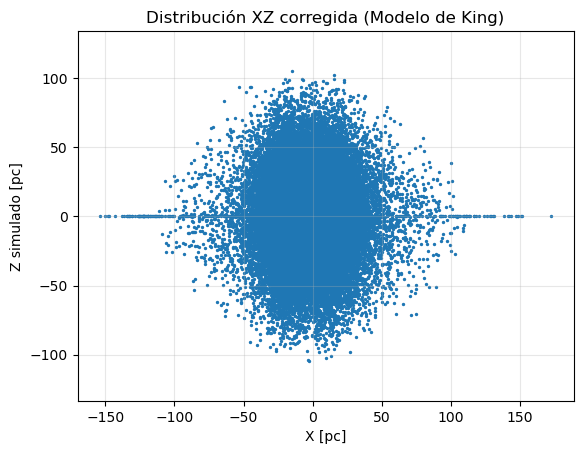

In [24]:
plt.scatter(X, Z_sim, s=2)
plt.title("Distribución XZ corregida (Modelo de King)")
plt.xlabel("X [pc]")
plt.ylabel("Z simulado [pc]")
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Ahora para volver de las coordenadas locales ($X$, $Y$, $Z_\text{sim}$) a las corodenadas observables en el cielo ($\alpha$, $\delta$) y a la nueva distancia corregida, se debe deshacer la proyección.

Se imagina el sistema de coordenadas centrado en el Sol. El centro del cúmulo está apuntando en la dirección dada por los vectores unitarios de su ascensión recta central ($\alpha_c$) y declinación central ($\delta_c$).

En el centro del cúmulo, el plano local tiene tres direcciones que son los vectores base:

* El eje X local ($\hat{u}_x$): Apunta hacia el Este (dirección en la que crece $\alpha$).
* El eje Y local ($\hat{u}_y$): Apunta hacia el Norte (dirección en la que crece $\delta$).
* El eje Z local ($\hat{u}_z$): Es la línea de la visual, apuntando radialmente desde el observador hacia afuera.

La posición 3D global de cualquier estrella será la suma vectorial de su posición transversal local ($X$, $Y$) y su distancia radial total. Como $Z_\text{sim}$ es la dispersión de profundidad respecto al centro, la distancia radial total de la estrella será la distancia al centro del cúmulo más esa dispersión ($d_c + Z_\text{sim}$).

Las coordenadas cartesianas globales $(X_g, Y_g, Z_g)$ de cada estrella se calculan así: $$\vec{r}_\star = X_\text{local} \hat{u}_x + Y_\text{local} \hat{u}_y + (d_c + Z_\text{sim}) \hat{u}_z$$

Y una vez se tiene $(X_g, Y_g, Z_g)$, usando trigonometría se devuelve a la esfera celeste.

In [25]:
def reconstruct_observation(X_local, Y_local, Z_sim, ra0, dec0, d0):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)

    # Vectores unitarios de la base local
    # Vector unitario hacia el Este (eje X local)
    ux_x = -np.sin(ra0)
    ux_y = np.cos(ra0)
    ux_z = 0.0

    # Vector unitario hacia el Norte (eje Y local)
    uy_x = -np.sin(dec0) * np.cos(ra0)
    uy_y = -np.sin(dec0) * np.sin(ra0)
    uy_z = np.cos(dec0)

    # Vector unitario Radial (eje Z local, aputando desde el observador)
    uz_x = np.cos(dec0) * np.cos(ra0)
    uz_y = np.cos(dec0) * np.sin(ra0)
    uz_z = np.sin(dec0)

    # La distancia total radial es la distancia al centro más la profundidad simulada
    Z_tot = d0 + Z_sim

    # Se calcula la posición cartesiana heliocéntrica global
    X = X_local * ux_x + Y_local * uy_x + Z_tot * uz_x
    Y = X_local * ux_y + Y_local * uy_y + Z_tot * uz_y
    Z = X_local * ux_z + Y_local * uy_z + Z_tot * uz_z

    # Se convierte de vuelta a esféricas
    ds = np.sqrt(X**2 + Y**2 + Z**2)

    ras = np.arctan2(Y, X)
    decs = np.arcsin(Z / ds)

    ras = np.degrees(ras)

    # Se normalizan los ángulos de ascensión recta al rango [0, 360)
    ras = np.mod(ras, 360.0)
    decs = np.degrees(decs)

    return ras, decs, ds

In [26]:
ras_sim, decs_sim, ds_sim = reconstruct_observation(X, Y, Z_sim, ra0, dec0, d0)

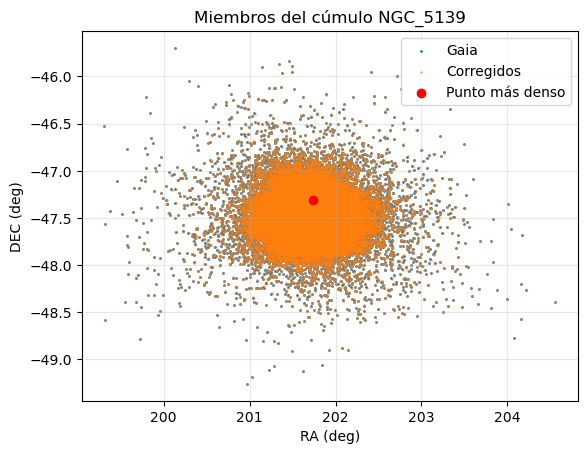

In [27]:
plt.scatter(ras, decs, s=1, label='Gaia')
plt.scatter(ras_sim, decs_sim, s=1, alpha=0.5, label='Corregidos')
plt.scatter(ra0, dec0, color='red', label='Punto más denso')
plt.xlabel('RA (deg)')
plt.ylabel('DEC (deg)')
plt.title(f'Miembros del cúmulo {cluster_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()